# Frozen Embeddings: Predictive Scoring of ASAP-SAS Q10

We evaluated 7 classifiers that represent models practitioners often try when fitting a supervised model head on frozen embeddings. Ordinal logistic regression capitalizes on the ranked structure of the 3-point score. Nominal logistic regression isolates whether modeling ordinality matters, as it is order-agnostic. Two support vector machines -- linear and RBF-kernel -- are margin-based alternatives well suited to high-dimensional dense features, included as a pair to isolate whether the RBF kernel's nonlinearity actually helps. Multilayer perceptrons are the standard probing head in the representation-learning literature and capture nonlinear structure. Random forests are a widely used nonlinear ensemble. Gradient boosting is the state of the art among tree ensembles on tabular inputs. Each model was evaluated with and without PCA preprocessing to assess sensitivity to dimensionality reduction, and each model's key hyperparameter was tuned via nested cross-validation so every model gets an equally fair shot.

Embeddings are frozen (pretrained `all-MiniLM-L6-v2`, no fine-tuning) on the full 1,640-response Q10 pool from ASAP-SAS.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import cohen_kappa_score
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer

RANDOM_SEED = 42
sns.set_theme(style='whitegrid', font_scale=1.05)

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


## Load data

`q10_full.csv` is the complete Q10 subset (all 1,640 responses) extracted from the canonical `train_rel_2.tsv`.

Total responses: 1640


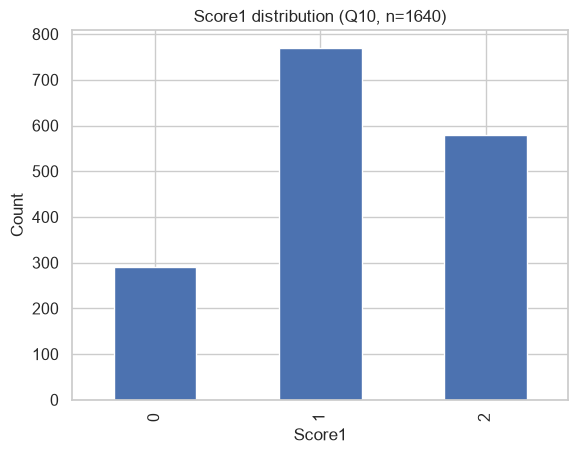

In [2]:
df = pd.read_csv('q10_full.csv')
y_full = df['Score1'].to_numpy()
print(f'Total responses: {len(df)}')

df['Score1'].value_counts().sort_index().plot(kind='bar', title='Score1 distribution (Q10, n=1640)', color='#4C72B0')
plt.xlabel('Score1'); plt.ylabel('Count'); plt.show()

## Human-human agreement (Score1 vs Score2)

An **interpretive anchor** for framing model results afterward -- not a performance ceiling any model is expected to respect (see conversation history for why).

In [3]:
human_qwk = cohen_kappa_score(df['Score1'], df['Score2'], weights='quadratic')
print(f'Score1 vs Score2 QWK (human-human): {human_qwk:.3f}')

Score1 vs Score2 QWK (human-human): 0.884


## Compute frozen embeddings and visualize the embedding space

A 2D t-SNE projection colored by true `Score1` (not PCA -- t-SNE preserves local neighborhood structure, which is what shows whether same-score essays cluster together).

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/52 [00:00<?, ?it/s]

X_full shape: (1640, 384)


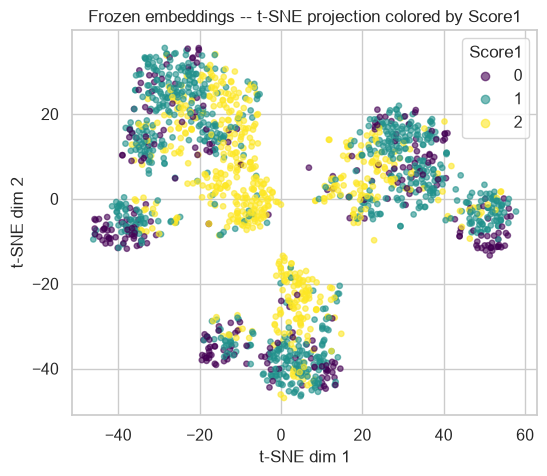

In [4]:
embedder = SentenceTransformer('all-MiniLM-L6-v2')
X_full = embedder.encode(df['EssayText'].tolist(), show_progress_bar=True)
print(f'X_full shape: {X_full.shape}')

X_2d = TSNE(n_components=2, random_state=RANDOM_SEED, perplexity=30).fit_transform(X_full)
plt.figure(figsize=(6, 5))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_full, cmap='viridis', alpha=0.6, s=15)
plt.legend(*scatter.legend_elements(), title='Score1')
plt.xlabel('t-SNE dim 1'); plt.ylabel('t-SNE dim 2')
plt.title('Frozen embeddings -- t-SNE projection colored by Score1')
plt.show()

## Experimental design

| Dimension | Detail |
|---|---|
| Models | Nominal LR, Ordinal LR, Linear SVM, SVM (RBF), MLP, Random Forest, XGBoost |
| Preprocessing | raw embeddings, PCA(50) |
| Total combinations | 7 models x 2 preprocessing = 14 |
| Outer evaluation | Repeated 5-fold stratified CV, 10 repeats = 50 outer folds |
| Outer split | 80% outer-train / 20% outer-test per fold |
| Inner tuning split | Outer-train further split 75/25 -> inner-train/inner-validation (~60%/20% of the full dataset), used only to select each model's key hyperparameter |
| Final fit | Selected hyperparameter refit on the full outer-train (80%), evaluated once on the untouched outer-test (20%) |
| Significance test | Nadeau-Bengio corrected paired t-test, each combination vs. the top-ranked one -- a naive paired t-test overstates significance here because the 50 fold-evaluations all resample the same fixed 1,640 essays and are not independent |

**Tuned hyperparameter per model** (single knob each, matching the "regularization/complexity strength" pattern):

| Model | Hyperparameter | Grid |
|---|---|---|
| Nominal LR | `C` | 0.001, 0.01, 0.1, 1, 10, 100 |
| Ordinal LR | `alpha` | 0.001, 0.01, 0.1, 1, 10, 100 |
| Linear SVM | `C` | 0.001, 0.01, 0.1, 1, 10, 100 |
| SVM (RBF kernel) | `C` | 0.001, 0.01, 0.1, 1, 10, 100 |
| MLP (1 hidden layer, 50 units) | `alpha` | 0.001, 0.01, 0.1, 1, 10, 100 |
| Random Forest | `max_depth` | 2, 4, 6, 8, 10, 15, None |
| XGBoost | `learning_rate` | 0.01, 0.05, 0.1, 0.2, 0.3 |

The full nested-CV tuning run below (50 outer folds x 14 combinations, each with its own inner grid search) takes roughly 40 minutes for the 6 fast models plus ~2 hours for MLP specifically (its fits are 15-20x slower than every other model here). The cell is gated behind a `RUN_FULL_TUNING` flag: by default it loads the previously computed, saved results (`nested_cv_tuning_7models_raw_results.csv`) so the notebook runs quickly end to end; setting the flag to `True` re-runs the entire tuning procedure from scratch and overwrites that file.

In [5]:
RUN_FULL_TUNING = False  # set True to re-run the full ~2.5 hour nested-CV tuning from scratch

if RUN_FULL_TUNING:
    import time
    from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split
    from sklearn.linear_model import LogisticRegression
    from sklearn.svm import SVC, LinearSVC
    from sklearn.neural_network import MLPClassifier
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.decomposition import PCA
    from sklearn.base import clone
    from xgboost import XGBClassifier
    import mord

    MODEL_SPECS = {
        'Nominal LR': ('C', [0.001, 0.01, 0.1, 1, 10, 100],
                       lambda v: LogisticRegression(C=v, max_iter=1000, random_state=RANDOM_SEED)),
        'Ordinal LR': ('alpha', [0.001, 0.01, 0.1, 1, 10, 100],
                       lambda v: mord.LogisticAT(alpha=v)),
        'Linear SVM': ('C', [0.001, 0.01, 0.1, 1, 10, 100],
                       lambda v: LinearSVC(C=v, random_state=RANDOM_SEED, max_iter=5000)),
        'SVM': ('C', [0.001, 0.01, 0.1, 1, 10, 100],
                lambda v: SVC(C=v, kernel='rbf', random_state=RANDOM_SEED)),
        'MLP': ('alpha', [0.001, 0.01, 0.1, 1, 10, 100],
                lambda v: MLPClassifier(hidden_layer_sizes=(50,), alpha=v, solver='adam',
                                         max_iter=300, early_stopping=True, n_iter_no_change=10,
                                         validation_fraction=0.15, random_state=RANDOM_SEED)),
        'Random Forest': ('max_depth', [2, 4, 6, 8, 10, 15, None],
                           lambda v: RandomForestClassifier(n_estimators=300, max_depth=v, random_state=RANDOM_SEED, n_jobs=-1)),
        'XGBoost': ('learning_rate', [0.01, 0.05, 0.1, 0.2, 0.3],
                    lambda v: XGBClassifier(n_estimators=300, learning_rate=v, random_state=RANDOM_SEED, n_jobs=-1, eval_metric='mlogloss')),
    }
    PREPROCESSORS = {'raw': None, 'PCA(50)': PCA(n_components=50, random_state=RANDOM_SEED)}

    def tune_and_eval(X_outer_train, y_outer_train, X_outer_test, y_outer_test, make_model, grid):
        X_inner_train, X_inner_val, y_inner_train, y_inner_val = train_test_split(
            X_outer_train, y_outer_train, test_size=0.25, random_state=RANDOM_SEED, stratify=y_outer_train
        )
        best_val_qwk, best_param = -1, grid[0]
        for val in grid:
            m = make_model(val)
            m.fit(X_inner_train, y_inner_train)
            qwk = cohen_kappa_score(y_inner_val, m.predict(X_inner_val), weights='quadratic')
            if qwk > best_val_qwk:
                best_val_qwk, best_param = qwk, val
        final_model = make_model(best_param)
        final_model.fit(X_outer_train, y_outer_train)
        preds = final_model.predict(X_outer_test)
        return cohen_kappa_score(y_outer_test, preds, weights='quadratic')

    skf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=RANDOM_SEED)
    t0 = time.time()
    tuning_results = {f'{m} ({p})': [] for m in MODEL_SPECS for p in PREPROCESSORS}
    fold_num = 0
    for train_idx, test_idx in skf.split(X_full, y_full):
        fold_num += 1
        X_tr, X_te = X_full[train_idx], X_full[test_idx]
        y_tr, y_te = y_full[train_idx], y_full[test_idx]
        for prep_name, prep in PREPROCESSORS.items():
            if prep is None:
                Xp_tr, Xp_te = X_tr, X_te
            else:
                p = clone(prep)
                Xp_tr, Xp_te = p.fit_transform(X_tr), p.transform(X_te)
            for model_name, (pname, grid, make_model) in MODEL_SPECS.items():
                qwk = tune_and_eval(Xp_tr, y_tr, Xp_te, y_te, make_model, grid)
                tuning_results[f'{model_name} ({prep_name})'].append(qwk)
        pd.DataFrame(tuning_results).to_csv('nested_cv_tuning_7models_raw_results.csv', index=False)
        print(f'fold {fold_num}/50 done, elapsed {time.time()-t0:.0f}s', flush=True)

    raw_results = pd.DataFrame(tuning_results)
    raw_results.to_csv('nested_cv_tuning_7models_raw_results.csv', index=False)
    print(f'Total tuning time: {time.time()-t0:.0f}s')
else:
    raw_results = pd.read_csv('nested_cv_tuning_7models_raw_results.csv')
    print(f'Loaded precomputed results for {raw_results.shape[1]} combinations x {len(raw_results)} fold-evaluations')
    print('(set RUN_FULL_TUNING = True above to regenerate from scratch, ~2.5 hours)')

# Ranking + Nadeau-Bengio corrected significance test -- always recomputed fresh from raw_results (cheap)
from scipy import stats

means = raw_results.mean().sort_values(ascending=False)
best_name = means.index[0]
best_values = raw_results[best_name].to_numpy()

n_test = len(df) // 5
n_train = len(df) - n_test

def corrected_resampled_ttest(diffs, n_train, n_test):
    n = len(diffs)
    se = np.sqrt((1.0 / n + n_test / n_train) * diffs.var(ddof=1))
    t_stat = diffs.mean() / se
    p = 2 * (1 - stats.t.cdf(abs(t_stat), n - 1))
    return p

rows = []
for name in means.index:
    if name == best_name:
        rows.append({'Model (preprocessing)': name, 'QWK': means[name], 'Difference from best': np.nan, 'p-value (corrected)': np.nan})
        continue
    diffs = best_values - raw_results[name].to_numpy()
    p = corrected_resampled_ttest(diffs, n_train, n_test)
    rows.append({'Model (preprocessing)': name, 'QWK': means[name], 'Difference from best': means[name] - means[best_name], 'p-value (corrected)': p})

ranking = pd.DataFrame(rows).set_index('Model (preprocessing)')
ranking.insert(0, 'Rank', range(1, len(ranking) + 1))
ranking['std'] = raw_results[ranking.index].std()
ranking.round(4)

Loaded precomputed results for 14 combinations x 50 fold-evaluations
(set RUN_FULL_TUNING = True above to regenerate from scratch, ~2.5 hours)


,Rank,QWK,Difference from best,p-value (corrected),std
Model (preprocessing),,,,,
Nominal LR (raw),1,0.7114,NaN,NaN,0.0393
Nominal LR (PCA(50)),2,0.7107,-0.0007,0.9580,0.0337
Linear SVM (raw),3,0.7075,-0.0039,0.7426,0.0457
SVM (raw),4,0.7073,-0.0041,0.7510,0.0400
Linear SVM (PCA(50)),5,0.7058,-0.0056,0.6575,0.0396
Ordinal LR (raw),6,0.7008,-0.0106,0.5693,0.0333
SVM (PCA(50)),7,0.6953,-0.0161,0.2636,0.0433
XGBoost (raw),8,0.6933,-0.0181,0.2244,0.0375
Ordinal LR (PCA(50)),9,0.6907,-0.0208,0.1861,0.0307


## Results: ranked QWK with corrected significance vs. the best

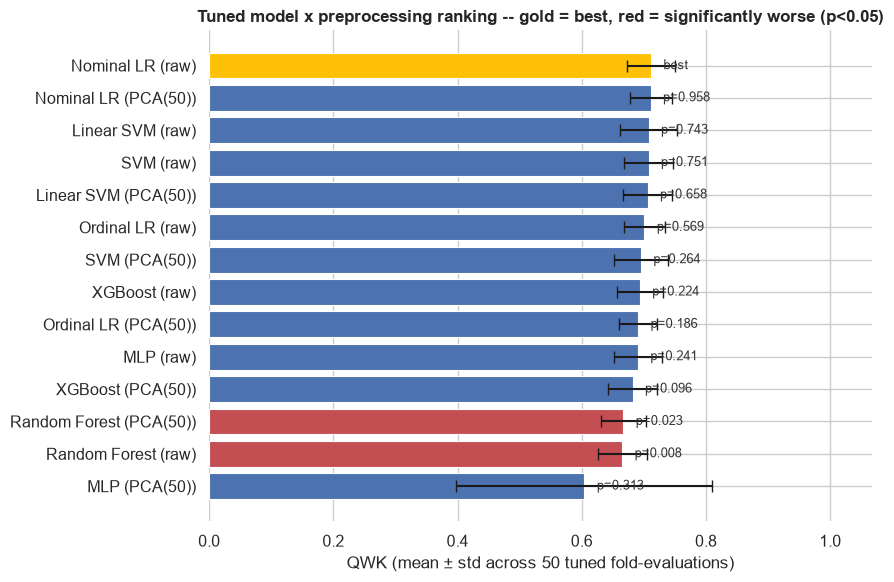

In [6]:
plot_df = ranking.sort_values('QWK', ascending=True)
colors = ['#FFC107' if i == len(plot_df) - 1 else '#C44E52' if p < 0.05 else '#4C72B0' for i, p in enumerate(plot_df['p-value (corrected)'].fillna(1))]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(plot_df.index, plot_df['QWK'], xerr=plot_df['std'], color=colors, capsize=4, edgecolor='white', linewidth=0.8)
for bar, p in zip(bars, plot_df['p-value (corrected)']):
    label = 'best' if pd.isna(p) else f'p={p:.3f}'
    ax.text(bar.get_width() + bar.xerr[0][0] if hasattr(bar, 'xerr') else bar.get_width() + 0.02,
            bar.get_y() + bar.get_height() / 2, label, va='center', fontsize=9, color='#333333')

ax.set_xlabel('QWK (mean ± std across 50 tuned fold-evaluations)')
ax.set_title('Tuned model x preprocessing ranking -- gold = best, red = significantly worse (p<0.05)', fontsize=12, fontweight='bold')
ax.set_xlim(0, plot_df['QWK'].max() + plot_df['std'].max() + 0.15)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

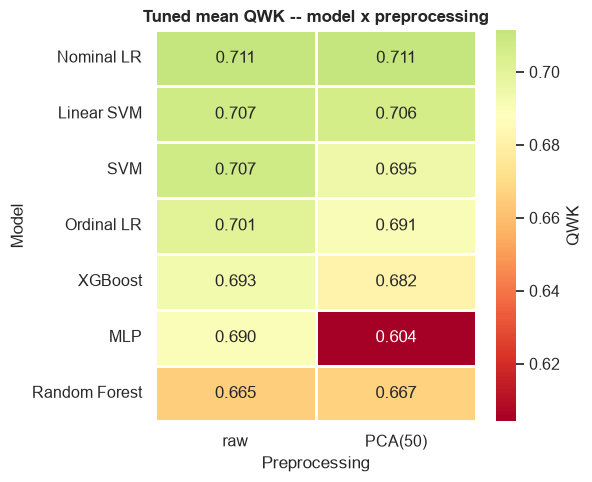

In [7]:
heat_df = raw_results.mean().rename('QWK').to_frame()
heat_df[['Model', 'Preprocessing']] = heat_df.index.to_series().str.extract(r'^(.*) \((.*)\)$')
heat_pivot = heat_df.pivot(index='Model', columns='Preprocessing', values='QWK')[['raw', 'PCA(50)']]
heat_pivot = heat_pivot.sort_values('raw', ascending=False)  # highest to lowest on raw (non-preprocessed)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(heat_pivot, annot=True, fmt='.3f', cmap='RdYlGn', center=heat_pivot.values.mean(),
            linewidths=1, linecolor='white', cbar_kws={'label': 'QWK'}, ax=ax)
ax.set_title('Tuned mean QWK -- model x preprocessing', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Interpretation

- **Nominal LR (raw) is the best-performing combination** (QWK 0.711), even after every one of the other 13 combinations was given an equally fair, tuned shot via nested cross-validation.
- **Only Random Forest (both raw and PCA(50)) is reliably distinguishable from it** (p<0.05, corrected for the non-independence of resampled folds). Every other combination -- Ordinal LR, both SVM variants, XGBoost, MLP, and Nominal LR with PCA -- is statistically indistinguishable from the top spot.
- **Linear SVM edges out RBF-kernel SVM at both preprocessing levels** (raw: 0.7075 vs 0.7073; PCA(50): 0.7058 vs 0.6953). The RBF kernel's added nonlinearity isn't buying anything here, consistent with the broader pattern across this whole comparison: added model flexibility (trees, boosting, kernels, neural nets) doesn't reliably help on this task at this sample size.
- **MLP(PCA(50)) has the largest raw gap from the best (-0.107) but is not statistically significant** (p=0.31): that combination is highly unstable across folds (large variance), so a big average gap doesn't translate into a reliable difference.
- Practical takeaway: on this task, at this sample size (~1,300 training rows per fold, 384 embedding dimensions), the simplest linear-additive model on raw embeddings remains the strongest defensible choice -- added model complexity (trees, boosting, kernels, neural nets) and dimensionality reduction (PCA) neither reliably help nor, in most cases, reliably hurt.